In [1]:
import json
import random
import glob
import sys
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

sys.path.insert(0, str(Path('..').resolve()))
from src.benchmark.hiddenbench_loader import HiddenBenchLoader
from src.viz.thesis_style import (
    apply_style, T_COLORS, DS_COLORS, BLUE, ORANGE, GREEN, VERM, PURPLE, SKY,
)

apply_style()
PALETTE = [BLUE, ORANGE, GREEN, VERM, PURPLE, SKY]
loader = HiddenBenchLoader()
DATA_DIR = Path('../results/mas/final_dataset_new_system_hiddenbench')

## Data loading

Key insight: `random.seed(qid)` is called **once per question** before all repetitions,
so agent *i* always holds the same hidden fact(s) across all 50 reps of the same question.
This lets us study whether structural position or private-information quality determines influence.

In [2]:
def _majority(votes):
    c = Counter(votes)
    return c.most_common(1)[0][0]


def _hub_id(topo):
    return int(np.argmax([sum(row) for row in topo]))


def reconstruct_agent_facts(qid):
    """Returns dict {agent_id: [hidden_fact_strings]}."""
    task = loader.load_single(qid)
    random.seed(qid)
    hidden = list(task.hidden_info)
    random.shuffle(hidden)
    agent_facts = {i: [] for i in range(len(hidden))}
    for idx, fact in enumerate(hidden):
        agent_facts[idx % len(hidden)].append(fact)
    random.seed(None)
    return agent_facts, task


def load_all_reps():
    rows = []
    for cfg_dir in sorted(DATA_DIR.iterdir()):
        if not cfg_dir.is_dir():
            continue
        cfg = cfg_dir.name
        w = int(cfg.split('_')[0][1:])
        topo = cfg.split('_')[1]

        for fp in sorted(cfg_dir.glob('*.json')):
            d = json.loads(fp.read_text())
            qid = int(d['question_id'])
            gt = d['ground_truth']
            agent_facts, _ = reconstruct_agent_facts(qid)

            for rep in d['repetitions']:
                rep_id = rep['repetition']
                rep_topo = rep['topology']
                hub = _hub_id(rep_topo) if topo == 'star' else None

                r0 = rep['trajectory'][0]['phase_b']
                rf = rep['trajectory'][-1]['phase_b']

                init_votes = {e['id']: e['vote'] for e in r0}
                init_conf = {e['id']: e['confidence'] for e in r0}
                final_votes = {e['id']: e['vote'] for e in rf}

                init_majority = _majority(list(init_votes.values()))
                final_majority = _majority(list(final_votes.values()))
                group_correct = final_majority == gt
                init_correct_group = init_majority == gt

                for agent_id in range(4):
                    iv = init_votes[agent_id]
                    fv = final_votes[agent_id]
                    rows.append({
                        'qid': qid,
                        'config': cfg,
                        'W': w,
                        'topo': topo,
                        'rep': rep_id,
                        'agent_id': agent_id,
                        'init_vote': iv,
                        'final_vote': fv,
                        'ground_truth': gt,
                        'init_correct': iv == gt,
                        'final_correct': fv == gt,
                        'init_conf': init_conf[agent_id],
                        'group_correct': group_correct,
                        'init_correct_group': init_correct_group,
                        'init_majority': init_majority,
                        'final_majority': final_majority,
                        'init_vote_prevails': iv == final_majority,
                        'is_hub': (agent_id == hub) if hub is not None else None,
                        'hidden_fact': agent_facts[agent_id][0] if agent_facts[agent_id] else None,
                    })
    return pd.DataFrame(rows)


df = load_all_reps()
print(f'Rows: {len(df):,}  |  Questions: {df.qid.nunique()}  |  Configs: {df.config.nunique()}')
df.head(3)

Rows: 60,000  |  Questions: 50  |  Configs: 6


,qid,config,W,topo,rep,agent_id,init_vote,final_vote,ground_truth,init_correct,final_correct,init_conf,group_correct,init_correct_group,init_majority,final_majority,init_vote_prevails,is_hub,hidden_fact
0,1,W1_fc,1,fc,0,0,A,C,A,True,False,7,False,False,C,C,False,None,A massive fire has blocked the supply truck an...
1,1,W1_fc,1,fc,0,1,C,C,A,False,False,8,False,False,C,C,True,None,The river level is just below the bridge to We...
2,1,W1_fc,1,fc,0,2,B,C,A,False,False,8,False,False,C,C,False,None,The supply truck headed to the village from Ea...


## 1. Per-agent-position initial accuracy

Because the hidden fact assignment is fixed per question (same `random.seed(qid)` every time),
agent 0 always holds the same private fact for a given question across all repetitions.
Across questions, different positions receive facts with different decisiveness.
We measure **individual accuracy at round 0** (before any communication) per agent position.

In [3]:
# One row per rep per agent (W1_fc as canonical reference)
ref = df[df['config'] == 'W1_fc'].copy()

pos_acc = (
    ref.groupby('agent_id')['init_correct']
    .agg(['mean', 'count', 'std'])
    .rename(columns={'mean': 'accuracy', 'count': 'n', 'std': 'sd'})
)
pos_acc['se'] = pos_acc['sd'] / np.sqrt(pos_acc['n'])
pos_acc['ci95'] = 1.96 * pos_acc['se']
print('Individual initial accuracy per agent position (W1_fc):')
print(pos_acc.round(3))

# Compare to group initial accuracy
grp_init = ref.drop_duplicates(['qid', 'rep'])['init_correct_group'].mean()
grp_final = ref.drop_duplicates(['qid', 'rep'])['group_correct'].mean()
ind_mean = ref['init_correct'].mean()
print(f'\nMean individual accuracy t=0: {ind_mean:.3f}')
print(f'Group accuracy t=0 (majority): {grp_init:.3f}')
print(f'Group accuracy final:          {grp_final:.3f}')

Individual initial accuracy per agent position (W1_fc):
          accuracy     n     sd     se   ci95
agent_id                                     
0            0.091  2500  0.287  0.006  0.011
1            0.121  2500  0.326  0.007  0.013
2            0.158  2500  0.365  0.007  0.014
3            0.200  2500  0.400  0.008  0.016

Mean individual accuracy t=0: 0.142
Group accuracy t=0 (majority): 0.071
Group accuracy final:          0.252


In [4]:
# Per-question: which agent position starts correct most often?
q_pos_acc = (
    ref.groupby(['qid', 'agent_id'])['init_correct']
    .mean()
    .unstack('agent_id')
)
# For each question, rank agent positions by initial accuracy
q_pos_acc['best_agent'] = q_pos_acc.idxmax(axis=1)
print('Distribution of "most-informed" agent position across questions:')
print(q_pos_acc['best_agent'].value_counts())

Distribution of "most-informed" agent position across questions:
best_agent
3    21
2    13
1     9
0     7
Name: count, dtype: int64


## 2. Information holder influence

**Influence**: does the agent's initial vote become the final group majority?

We split agents into *informed* (initial vote = correct) and *uninformed* (initial vote = wrong)
and compare their influence scores.

In [5]:
# Influence = P(agent's initial vote == final group majority)
inf_by_group = (
    ref.groupby('init_correct')['init_vote_prevails']
    .agg(['mean', 'count', 'std'])
    .rename(columns={'mean': 'influence', 'count': 'n'})
)
inf_by_group['se'] = inf_by_group['std'] / np.sqrt(inf_by_group['n'])
inf_by_group.index = inf_by_group.index.map({True: 'Informed (correct t=0)', False: 'Uninformed (wrong t=0)'})
print('Influence score by initial correctness (W1_fc):')
print(inf_by_group[['influence', 'n', 'se']].round(3))

# Per-position influence
pos_inf = (
    ref.groupby('agent_id')['init_vote_prevails']
    .mean()
    .rename('influence')
)
print('\nInfluence per agent position:')
print(pos_inf.round(3))

Influence score by initial correctness (W1_fc):
                        influence     n     se
init_correct                                  
Uninformed (wrong t=0)      0.545  8575  0.005
Informed (correct t=0)      0.542  1425  0.013

Influence per agent position:
agent_id
0    0.532
1    0.539
2    0.551
3    0.557
Name: influence, dtype: float64


In [6]:
# Across all configs: informed vs uninformed influence
inf_cfg = (
    df.groupby(['config', 'init_correct'])['init_vote_prevails']
    .mean()
    .unstack('init_correct')
    .rename(columns={True: 'informed', False: 'uninformed'})
)
inf_cfg['advantage'] = inf_cfg['informed'] - inf_cfg['uninformed']
print('Informed vs uninformed influence across configs:')
print(inf_cfg.round(3))

Informed vs uninformed influence across configs:
init_correct  uninformed  informed  advantage
config                                       
W1_fc              0.545     0.542     -0.003
W1_star            0.540     0.512     -0.028
W2_fc              0.523     0.560      0.036
W2_star            0.521     0.540      0.020
W5_fc              0.540     0.540     -0.000
W5_star            0.519     0.540      0.021


## 3. "Loud vs Informed": confidence vs initial correctness

If the agent with the decisive private fact is MORE confident, the group likely succeeds.
If wrong agents are more confident (louder), they can dominate the discussion.

We test: is round-0 confidence correlated with initial correctness?
And: among cases where the group ends up WRONG despite having an informed agent,
are the wrong agents more confident on average?

In [7]:
# Correlation: confidence vs correctness at round 0
rho, p = stats.pointbiserialr(ref['init_correct'].astype(int), ref['init_conf'])
print(f'Point-biserial r(correctness, confidence) = {rho:.3f}, p = {p:.4f}')

conf_by_correct = ref.groupby('init_correct')['init_conf'].agg(['mean', 'std', 'count'])
conf_by_correct.index = conf_by_correct.index.map({True: 'Correct', False: 'Wrong'})
print('\nMean confidence at t=0 by initial correctness:')
print(conf_by_correct.round(3))

Point-biserial r(correctness, confidence) = -0.092, p = 0.0000

Mean confidence at t=0 by initial correctness:
               mean   std  count
init_correct                    
Wrong         7.386  0.71   8575
Correct       7.198  0.73   1425


In [8]:
# "Cascade failure" analysis: reps where an informed agent exists but group ends wrong
rep_level = (
    ref.groupby(['qid', 'rep'])
    .agg(
        any_informed=('init_correct', 'any'),
        n_informed=('init_correct', 'sum'),
        mean_conf_informed=('init_conf', lambda x: x[ref.loc[x.index, 'init_correct']].mean()),
        mean_conf_uninformed=('init_conf', lambda x: x[~ref.loc[x.index, 'init_correct']].mean()),
        group_correct=('group_correct', 'first'),
    )
    .reset_index()
)

informed_group = rep_level[rep_level['any_informed']]
success = informed_group[informed_group['group_correct']]
failure = informed_group[~informed_group['group_correct']]

print(f'Reps with ≥1 informed agent: {len(informed_group):,}')
print(f'  → Group correct (info used): {len(success):,} ({len(success)/len(informed_group):.1%})')
print(f'  → Group wrong (info wasted): {len(failure):,} ({len(failure)/len(informed_group):.1%})')

print(f'\nIn info-wasted failures:')
print(f'  Mean conf of informed agent:   {failure["mean_conf_informed"].mean():.2f}')
print(f'  Mean conf of uninformed agents:{failure["mean_conf_uninformed"].mean():.2f}')
print(f'\nIn successful info-use:')
print(f'  Mean conf of informed agent:   {success["mean_conf_informed"].mean():.2f}')
print(f'  Mean conf of uninformed agents:{success["mean_conf_uninformed"].mean():.2f}')

Reps with ≥1 informed agent: 1,105
  → Group correct (info used): 501 (45.3%)
  → Group wrong (info wasted): 604 (54.7%)

In info-wasted failures:
  Mean conf of informed agent:   7.15
  Mean conf of uninformed agents:7.39

In successful info-use:
  Mean conf of informed agent:   7.24
  Mean conf of uninformed agents:7.45


In [9]:
# Confidence ADVANTAGE of informed agent: conf_informed - mean_conf_uninformed
rep_level['conf_advantage'] = rep_level['mean_conf_informed'] - rep_level['mean_conf_uninformed']

# Re-slice so they pick up the new column
informed_group = rep_level[rep_level['any_informed']].copy()
success = informed_group[informed_group['group_correct']]
failure = informed_group[~informed_group['group_correct']]

adv_success = success['conf_advantage']
adv_failure = failure['conf_advantage']
t, p = stats.ttest_ind(adv_success.dropna(), adv_failure.dropna())
print(f'Confidence advantage (informed - uninformed):')
print(f'  Success: {adv_success.mean():.3f} ± {adv_success.std():.3f}')
print(f'  Failure: {adv_failure.mean():.3f} ± {adv_failure.std():.3f}')
print(f'  t-test: t={t:.2f}, p={p:.4f}')

Confidence advantage (informed - uninformed):
  Success: -0.218 ± 0.723
  Failure: -0.239 ± 0.808
  t-test: t=0.46, p=0.6439


## 4. Star topology: hub information advantage

In star topology the hub sees ALL agents' messages, while leaves only see the hub.
If the hub holds the decisive private fact (votes correctly at t=0),
does the group succeed more often than when the hub votes incorrectly?

In [10]:
star_df = df[df['topo'] == 'star'].copy()

# Per-rep: hub agent's initial correctness
hub_rows = star_df[star_df['is_hub'] == True]
rep_hub = hub_rows[['qid', 'config', 'rep', 'init_correct', 'group_correct']].copy()
rep_hub.columns = ['qid', 'config', 'rep', 'hub_init_correct', 'group_correct']

hub_effect = (
    rep_hub.groupby('hub_init_correct')['group_correct']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'group_accuracy', 'count': 'n'})
)
hub_effect.index = hub_effect.index.map({True: 'Hub correct t=0', False: 'Hub wrong t=0'})
print('Star topology — group accuracy by hub initial correctness:')
print(hub_effect.round(3))

# Compare to FC group accuracy (same questions, same W)
for w in [1, 2, 5]:
    fc_acc = df[(df['config'] == f'W{w}_fc')].drop_duplicates(['qid','rep'])['group_correct'].mean()
    st_acc = df[(df['config'] == f'W{w}_star')].drop_duplicates(['qid','rep'])['group_correct'].mean()
    print(f'W={w}: FC={fc_acc:.3f}  Star={st_acc:.3f}')

Star topology — group accuracy by hub initial correctness:
                  group_accuracy     n
hub_init_correct                      
Hub wrong t=0              0.195  6373
Hub correct t=0            0.617  1127
W=1: FC=0.252  Star=0.245
W=2: FC=0.282  Star=0.266
W=5: FC=0.258  Star=0.264


In [11]:
# Hub vs leaf influence comparison in star
star_inf = (
    star_df.groupby('is_hub')['init_vote_prevails']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'influence', 'count': 'n'})
)
star_inf.index = star_inf.index.map({True: 'Hub', False: 'Leaf'})
print('Star topology — influence by hub/leaf role:')
print(star_inf.round(3))

# Hub influence when hub is informed vs uninformed
hub_inf = hub_rows.groupby('init_correct')['init_vote_prevails'].agg(['mean', 'count'])
hub_inf.index = hub_inf.index.map({True: 'Hub informed', False: 'Hub uninformed'})
print('\nHub influence by hub initial correctness:')
print(hub_inf.round(3))

Star topology — influence by hub/leaf role:
        influence      n
is_hub                  
Leaf        0.512  22500
Hub         0.571   7500

Hub influence by hub initial correctness:
                 mean  count
init_correct                
Hub uninformed  0.563   6373
Hub informed    0.617   1127


## 5. Fact propagation through messages

Do agents effectively *communicate* their private hidden facts?
We use keyword matching: extract distinctive words from each agent's hidden fact,
then track how many agents mention those keywords per round.

In [12]:
STOPWORDS = {
    'the','a','an','is','are','was','were','be','been','being','have','has','had',
    'do','does','did','will','would','could','should','may','might','must','shall',
    'to','of','in','on','at','by','for','with','about','from','into','through',
    'and','or','but','if','as','that','this','which','who','what','when','where',
    'all','not','no','its','it','they','we','you','he','she','our','their','your',
}

def fact_keywords(fact_text, min_len=5):
    words = fact_text.lower().split()
    return [w.strip('.,!?;:"\"') for w in words if len(w) >= min_len and w not in STOPWORDS]


def message_mentions_fact(message, keywords, threshold=2):
    msg = message.lower()
    return sum(1 for kw in keywords if kw in msg) >= threshold


def fact_propagation_for_run(rep_data, agent_facts, gt):
    """Returns list of dicts: {round, agent_id, holder_id, mentioned}."""
    traj = rep_data['trajectory']
    rows = []
    for holder_id, facts in agent_facts.items():
        if not facts:
            continue
        keywords = fact_keywords(facts[0])
        if len(keywords) < 2:
            continue
        for rnd in traj:
            round_num = rnd['round']
            for entry in rnd['phase_b']:
                mentioned = message_mentions_fact(entry.get('message', ''), keywords)
                rows.append({
                    'round': round_num,
                    'agent_id': entry['id'],
                    'holder_id': holder_id,
                    'mentioned': mentioned,
                    'is_holder': entry['id'] == holder_id,
                })
    return rows

In [13]:
# Run propagation analysis on W1_fc (small sample first)
prop_rows = []
fp_list = sorted((DATA_DIR / 'W1_fc').glob('*.json'))

for fp in fp_list:
    d = json.loads(fp.read_text())
    qid = int(d['question_id'])
    gt = d['ground_truth']
    agent_facts, _ = reconstruct_agent_facts(qid)

    for rep in d['repetitions']:
        group_correct = rep['correct']
        r0 = rep['trajectory'][0]['phase_b']
        agent_init_correct = {e['id']: (e['vote'] == gt) for e in r0}

        rows = fact_propagation_for_run(rep, agent_facts, gt)
        for row in rows:
            row['qid'] = qid
            row['rep'] = rep['repetition']
            row['group_correct'] = group_correct
            row['holder_init_correct'] = agent_init_correct.get(row['holder_id'], None)
            prop_rows.append(row)

prop_df = pd.DataFrame(prop_rows)
print(f'Propagation rows: {len(prop_df):,}')
prop_df.head(3)

Propagation rows: 247,152


,round,agent_id,holder_id,mentioned,is_holder,qid,rep,group_correct,holder_init_correct
0,0,0,0,False,True,1,0,False,True
1,0,1,0,False,False,1,0,False,True
2,0,2,0,False,False,1,0,False,True


In [14]:
# Spread rate: % of non-holder agents mentioning the fact, by round
non_holder = prop_df[~prop_df['is_holder']]
spread_by_round = non_holder.groupby('round')['mentioned'].mean()
print('Fact spread rate (non-holder mention %) by round:')
print((spread_by_round * 100).round(1))

# Holder self-mention rate
holder = prop_df[prop_df['is_holder']]
holder_mention = holder.groupby('round')['mentioned'].mean()
print('\nHolder self-mention rate by round:')
print((holder_mention * 100).round(1))

Fact spread rate (non-holder mention %) by round:
round
0     43.7
1     63.1
2     67.3
3     70.0
4     70.5
5     70.9
6     71.4
7     71.9
8     72.8
9     73.4
10    73.2
11    74.2
12    72.4
13    73.3
14    72.4
15    70.9
Name: mentioned, dtype: float64

Holder self-mention rate by round:
round
0     53.4
1     63.0
2     67.7
3     70.4
4     70.7
5     70.6
6     70.8
7     71.5
8     71.9
9     72.9
10    72.0
11    73.6
12    74.2
13    71.4
14    70.7
15    69.4
Name: mentioned, dtype: float64


In [15]:
# Does decisive fact (holder votes correctly at t=0) spread MORE than non-decisive fact?
spread_by_decisive = (
    non_holder[non_holder['round'] >= 1]
    .groupby('holder_init_correct')['mentioned']
    .mean()
)
spread_by_decisive.index = spread_by_decisive.index.map({True: 'Decisive (holder correct)', False: 'Non-decisive (holder wrong)'})
print('Spread rate for decisive vs non-decisive hidden facts (rounds 1+):')
print((spread_by_decisive * 100).round(1))

# And does it lead to better outcomes?
decisive_spread = non_holder[non_holder['holder_init_correct'] == True]
spread_by_outcome = decisive_spread.groupby(['group_correct', 'round'])['mentioned'].mean().unstack('round')
print('\nDecisive-fact spread by group outcome:')
print((spread_by_outcome * 100).round(1))

Spread rate for decisive vs non-decisive hidden facts (rounds 1+):
holder_init_correct
Non-decisive (holder wrong)    67.2
Decisive (holder correct)      77.8
Name: mentioned, dtype: float64

Decisive-fact spread by group outcome:
round            0     1     2     3     4     5     6     7     8     9   \
group_correct                                                               
False          38.3  68.3  71.5  73.0  71.9  70.4  71.8  69.7  69.0  71.6   
True           46.4  79.0  82.6  85.5  86.1  84.2  85.7  86.7  88.1  89.4   

round            10    11    12    13    14    15  
group_correct                                      
False          71.7  73.4  71.7  71.7  76.0  78.2  
True           88.0  88.7  87.6  97.6  94.2  90.2  


## 6. Per-question analysis: information difficulty

Some questions have hidden facts that strongly point to the correct answer (high individual accuracy).
Others have misleading or neutral facts — agents need to combine multiple private pieces.
We characterise each question by its *information landscape*.

In [16]:
q_stats = (
    ref.groupby('qid')
    .agg(
        ind_accuracy=('init_correct', 'mean'),
        n_agents_correct_t0=('init_correct', lambda x: x.sum() / (len(x) / 4)),  # mean per rep
        group_accuracy=('group_correct', lambda x: x.iloc[::4].mean()),  # one per rep
        mean_init_conf=('init_conf', 'mean'),
    )
    .reset_index()
)

# Add task name
q_stats['task_name'] = q_stats['qid'].apply(lambda q: loader.load_single(q).name[:30])

# Categorize by info landscape
q_stats['info_type'] = pd.cut(
    q_stats['ind_accuracy'],
    bins=[-0.01, 0.25, 0.50, 0.75, 1.01],
    labels=['Misleading (<25%)', 'Ambiguous (25-50%)', 'Partial (50-75%)', 'Clear (>75%)']
)

print('Info landscape distribution across 35 questions:')
print(q_stats['info_type'].value_counts())
print()
print(q_stats[['task_name', 'ind_accuracy', 'group_accuracy', 'info_type']]
      .sort_values('ind_accuracy').to_string(index=False))

Info landscape distribution across 35 questions:
info_type
Misleading (<25%)     42
Ambiguous (25-50%)     6
Partial (50-75%)       2
Clear (>75%)           0
Name: count, dtype: int64

                     task_name  ind_accuracy  group_accuracy          info_type
 emergency_supply_distribution         0.000            0.04  Misleading (<25%)
emergency_conference_relocatio         0.010            0.10  Misleading (<25%)
         evacuate_park_dilemma         0.010            0.32  Misleading (<25%)
emergency_aircraft_landing_sit         0.010            0.02  Misleading (<25%)
storm_recovery_clinic_site_sel         0.020            0.04  Misleading (<25%)
           artifact_safe_haven         0.025            0.24  Misleading (<25%)
          evacuation_east_town         0.030            0.04  Misleading (<25%)
     sensor_placement_decision         0.030            0.28  Misleading (<25%)
         The Artifact Delivery         0.040            0.02  Misleading (<25%)
        Secure

In [17]:
# Group accuracy improvement over individual, by info type
q_stats['improvement'] = q_stats['group_accuracy'] - q_stats['ind_accuracy']

by_type = q_stats.groupby('info_type')[['ind_accuracy', 'group_accuracy', 'improvement']].agg(['mean', 'std'])
print('Mean accuracy by info landscape type:')
print(by_type.round(3))

Mean accuracy by info landscape type:
                   ind_accuracy        group_accuracy        improvement  \
                           mean    std           mean    std        mean   
info_type                                                                  
Misleading (<25%)         0.100  0.064          0.194  0.137       0.094   
Ambiguous (25-50%)        0.300  0.036          0.487  0.234       0.187   
Partial (50-75%)          0.562  0.067          0.750  0.156       0.188   
Clear (>75%)                NaN    NaN            NaN    NaN         NaN   

                           
                      std  
info_type                  
Misleading (<25%)   0.118  
Ambiguous (25-50%)  0.217  
Partial (50-75%)    0.088  
Clear (>75%)          NaN  


/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_41636/1011820104.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_type = q_stats.groupby('info_type')[['ind_accuracy', 'group_accuracy', 'improvement']].agg(['mean', 'std'])


## 7. Cascade failure taxonomy

When groups FAIL despite having informed agents, we classify failure modes:
- **Outvoted**: informed agent is in the minority at t=0 (3 vs 1)
- **Capitulation**: informed agent changes to wrong answer during discussion
- **Deadlock → noise**: group starts split but converges to wrong answer

In [18]:
# Classify each failure rep
rep_agent = ref.groupby(['qid', 'rep'])

failure_rows = []
for (qid, rep_id), grp in rep_agent:
    gc = grp['group_correct'].iloc[0]
    n_informed = grp['init_correct'].sum()
    if gc or n_informed == 0:
        continue  # skip successes and reps with no informed agent

    # Check if any informed agent changed to wrong answer
    # (capitulation: init_correct=True but final_vote != ground_truth)
    informed_agents = grp[grp['init_correct']]
    capitulated = (informed_agents['final_correct'] == False).any()

    failure_rows.append({
        'qid': qid,
        'rep': rep_id,
        'n_informed': n_informed,
        'outvoted': n_informed < 2,  # minority at t=0
        'capitulated': capitulated,
    })

fail_df = pd.DataFrame(failure_rows)
print(f'Failure reps with ≥1 informed agent: {len(fail_df)}')
print(f'  Outvoted (solo informed):  {fail_df["outvoted"].sum()} ({fail_df["outvoted"].mean():.1%})')
print(f'  Capitulation occurred:     {fail_df["capitulated"].sum()} ({fail_df["capitulated"].mean():.1%})')
print(f'  Multi-agent outvoted:      {(~fail_df["outvoted"]).sum()} ({(~fail_df["outvoted"]).mean():.1%})')

Failure reps with ≥1 informed agent: 604


  Outvoted (solo informed):  557 (92.2%)
  Capitulation occurred:     603 (99.8%)
  Multi-agent outvoted:      47 (7.8%)


In [19]:
# Capitulation: compare confidence of informed agent who capitulates vs who holds position
cap_rows = []
for (qid, rep_id), grp in rep_agent:
    gc = grp['group_correct'].iloc[0]
    informed = grp[grp['init_correct']]
    if len(informed) == 0:
        continue
    for _, agent_row in informed.iterrows():
        cap_rows.append({
            'qid': qid,
            'rep': rep_id,
            'group_correct': gc,
            'init_conf': agent_row['init_conf'],
            'held_position': agent_row['final_correct'],
        })

cap_df = pd.DataFrame(cap_rows)
conf_by_position = cap_df.groupby('held_position')['init_conf'].agg(['mean', 'std', 'count'])
conf_by_position.index = conf_by_position.index.map({True: 'Held (correct final)', False: 'Capitulated (wrong final)'})
print('Informed-agent confidence by whether they held their correct position:')
print(conf_by_position.round(3))

t_cap, p_cap = stats.ttest_ind(
    cap_df[cap_df['held_position']]['init_conf'],
    cap_df[~cap_df['held_position']]['init_conf']
)
print(f'\nt-test: t={t_cap:.2f}, p={p_cap:.4f}')

Informed-agent confidence by whether they held their correct position:
                            mean    std  count
held_position                                 
Capitulated (wrong final)  7.162  0.749    654
Held (correct final)       7.228  0.712    771

t-test: t=1.71, p=0.0879


## 8. Summary: FC vs Star information integration

In [20]:
# Group accuracy per config
group_acc = (
    df.groupby('config')
    .apply(lambda g: g.drop_duplicates(['qid', 'rep'])['group_correct'].mean())
    .rename('group_accuracy')
    .reset_index()
)
group_acc[['W', 'topo']] = group_acc['config'].str.extract(r'W(\d)_(.*)')
group_acc['W'] = group_acc['W'].astype(int)

pivot = group_acc.pivot(index='W', columns='topo', values='group_accuracy')
pivot['fc_advantage'] = pivot['fc'] - pivot['star']
print('Group accuracy (final) by config:')
print(pivot.round(3))

Group accuracy (final) by config:
topo     fc   star  fc_advantage
W                               
1     0.252  0.245         0.007
2     0.282  0.266         0.016
5     0.258  0.264        -0.007


/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_41636/1694802208.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.drop_duplicates(['qid', 'rep'])['group_correct'].mean())


In [21]:
# Informed agent influence: FC vs Star
inf_topo = (
    df.groupby(['topo', 'init_correct'])['init_vote_prevails']
    .mean()
    .unstack('init_correct')
    .rename(columns={True: 'informed', False: 'uninformed'})
)
inf_topo['advantage'] = inf_topo['informed'] - inf_topo['uninformed']
print('Informed-agent influence advantage by topology:')
print(inf_topo.round(3))

Informed-agent influence advantage by topology:
init_correct  uninformed  informed  advantage
topo                                         
fc                 0.536     0.547      0.011
star               0.527     0.531      0.004


## 9. Visualisations

/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_41636/4133427721.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.drop_duplicates(['qid','rep'])['group_correct'].mean())


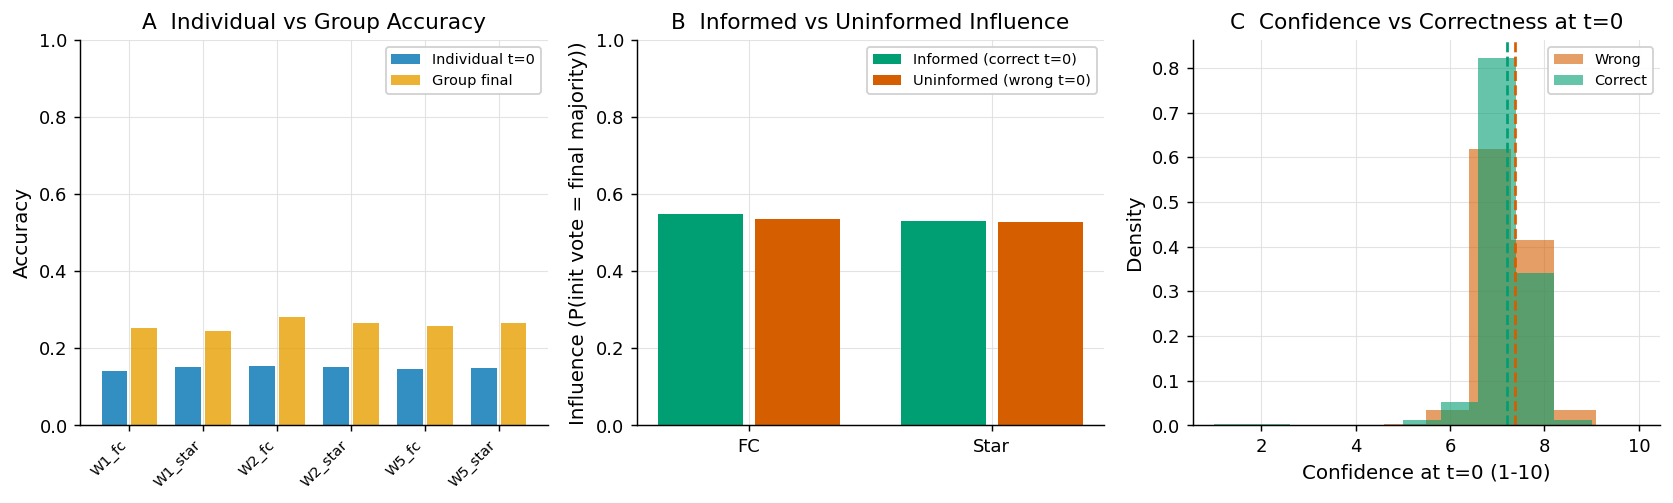

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# ── Panel A: individual vs group accuracy, by config ──────────────────────────
ax = axes[0]
ind_acc_cfg = df.groupby('config')['init_correct'].mean()
grp_acc_cfg = (
    df.groupby('config')
    .apply(lambda g: g.drop_duplicates(['qid','rep'])['group_correct'].mean())
)

x = np.arange(6)
cfgs = sorted(df['config'].unique())
ax.bar(x - 0.2, [ind_acc_cfg[c] for c in cfgs], 0.35, label='Individual t=0', color=PALETTE[0], alpha=0.8)
ax.bar(x + 0.2, [grp_acc_cfg[c] for c in cfgs], 0.35, label='Group final', color=PALETTE[1], alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(cfgs, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Accuracy')
ax.set_title('A  Individual vs Group Accuracy')
ax.legend(fontsize=8)
ax.set_ylim(0, 1)

# ── Panel B: informed vs uninformed influence by topology ──────────────────────
ax = axes[1]
topos = ['fc', 'star']
informed_inf = [inf_topo.loc[t, 'informed'] for t in topos]
uninformed_inf = [inf_topo.loc[t, 'uninformed'] for t in topos]

x2 = np.arange(len(topos))
ax.bar(x2 - 0.2, informed_inf, 0.35, label='Informed (correct t=0)', color=PALETTE[2])
ax.bar(x2 + 0.2, uninformed_inf, 0.35, label='Uninformed (wrong t=0)', color=PALETTE[3])
ax.set_xticks(x2)
ax.set_xticklabels(['FC', 'Star'])
ax.set_ylabel('Influence (P(init vote = final majority))')
ax.set_title('B  Informed vs Uninformed Influence')
ax.legend(fontsize=8)
ax.set_ylim(0, 1)

# ── Panel C: confidence at t=0 vs initial correctness ─────────────────────────
ax = axes[2]
wrong_conf = ref[~ref['init_correct']]['init_conf']
right_conf = ref[ref['init_correct']]['init_conf']
ax.hist(wrong_conf, bins=10, alpha=0.6, label='Wrong', color=PALETTE[3], density=True)
ax.hist(right_conf, bins=10, alpha=0.6, label='Correct', color=PALETTE[2], density=True)
ax.axvline(wrong_conf.mean(), color=PALETTE[3], linestyle='--', linewidth=1.5)
ax.axvline(right_conf.mean(), color=PALETTE[2], linestyle='--', linewidth=1.5)
ax.set_xlabel('Confidence at t=0 (1-10)')
ax.set_ylabel('Density')
ax.set_title('C  Confidence vs Correctness at t=0')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('hiddenbench_info_influence.png', dpi=150, bbox_inches='tight')
plt.show()

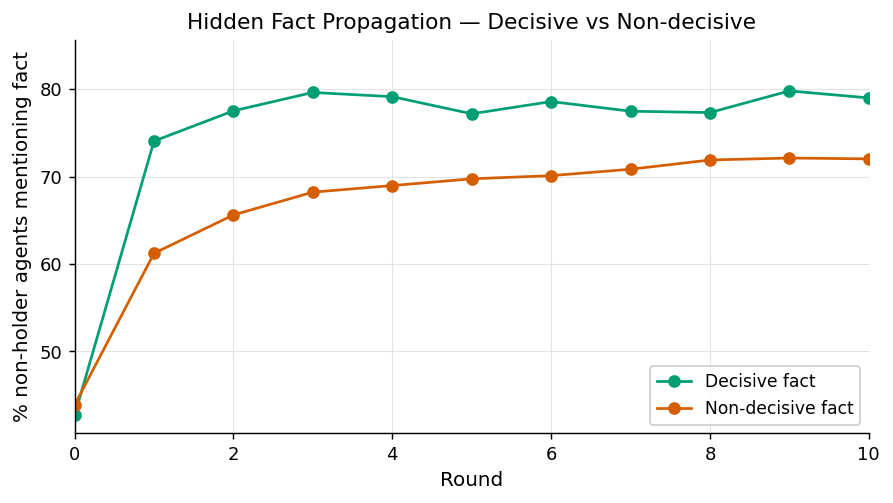

In [23]:
# Panel: fact spread over rounds (decisive vs non-decisive)
fig, ax = plt.subplots(figsize=(7, 4))

for decisive, label, color in [(True, 'Decisive fact', PALETTE[2]), (False, 'Non-decisive fact', PALETTE[3])]:
    subset = non_holder[non_holder['holder_init_correct'] == decisive]
    spread = subset.groupby('round')['mentioned'].mean()
    ax.plot(spread.index, spread.values * 100, marker='o', label=label, color=color)

ax.set_xlabel('Round')
ax.set_ylabel('% non-holder agents mentioning fact')
ax.set_title('Hidden Fact Propagation — Decisive vs Non-decisive')
ax.legend()
ax.set_xlim(0, 10)
plt.tight_layout()
plt.savefig('hiddenbench_fact_propagation.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Key findings summary

In [24]:
# Summary table
summary = {
    'Mean individual accuracy (t=0)': ref['init_correct'].mean(),
    'Group accuracy t=0 (majority)': ref.drop_duplicates(['qid','rep'])['init_correct_group'].mean(),
    'Group accuracy final (W1_fc)': ref.drop_duplicates(['qid','rep'])['group_correct'].mean(),
    'Informed agent influence (FC)': inf_topo.loc['fc', 'informed'],
    'Uninformed agent influence (FC)': inf_topo.loc['fc', 'uninformed'],
    'Informed agent influence (Star)': inf_topo.loc['star', 'informed'],
    'Uninformed agent influence (Star)': inf_topo.loc['star', 'uninformed'],
    'Point-biserial r(conf, correct)': rho,
    'Failure rate despite informed agent': len(failure) / len(informed_group),
    'Of failures: outvoted informed': fail_df['outvoted'].mean(),
    'Of failures: capitulation': fail_df['capitulated'].mean(),
}

for k, v in summary.items():
    print(f'  {k:<45} {v:.3f}')

  Mean individual accuracy (t=0)                0.142
  Group accuracy t=0 (majority)                 0.071
  Group accuracy final (W1_fc)                  0.252
  Informed agent influence (FC)                 0.547
  Uninformed agent influence (FC)               0.536
  Informed agent influence (Star)               0.531
  Uninformed agent influence (Star)             0.527
  Point-biserial r(conf, correct)               -0.092
  Failure rate despite informed agent           0.547
  Of failures: outvoted informed                0.922
  Of failures: capitulation                     0.998
